# BBH Remnants: Precessing Models

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

import numpy as np
import matplotlib.pyplot as plt
from gwGenealogy.binaries import BBHs, BBHRemnant, sample_masses, sample_spins
from gwGenealogy.utils import set_rcparams, compute_jensen_shannon_divergence

set_rcparams()

lal.MSUN_SI != Msun


## Sample BBH population

In [2]:
N = 5000
m1, m2 = sample_masses(N, m_min=5, m_max=50, m1_distribution='powerlaw', alpha=-2.35, seed=42)
chi1, chi2 = sample_spins(N, chi_max=1.0, spin_magnitude='beta', spin_angles='isotropic', beta_a=1.4, beta_b=3.6, seed=43)
bbh = BBHs(m1=m1, m2=m2, a1=np.linalg.norm(chi1, axis=1), a2=np.linalg.norm(chi2, axis=1),
           theta1=np.arccos(chi1[:,2]/np.linalg.norm(chi1, axis=1)),
           theta2=np.arccos(chi2[:,2]/np.linalg.norm(chi2, axis=1)),
           phi1=np.arctan2(chi1[:,1], chi1[:,0]) % (2*np.pi),
           phi2=np.arctan2(chi2[:,1], chi2[:,0]) % (2*np.pi))
print(bbh)

## Precessing remnants: default (HBR + gwmodel)

In [3]:
rem_gw = BBHRemnant(bbh=bbh, precessing=True)
print(rem_gw)

BBHRemnant(n=5000, precessing=True, mass_spin=hbr, kick=gwmodel, Mf=[9.5, 87.8], af=[0.133, 0.914], vkick=[0.2, 2360.3] km/s)


## Alternative: HBR + HLZ (CLZM2007)

In [4]:
rem_hlz = BBHRemnant(bbh=bbh, precessing=True, kick_model='hlz')
print(rem_hlz)

BBHRemnant(n=5000, precessing=True, mass_spin=hbr, kick=hlz, Mf=[9.5, 87.8], af=[0.133, 0.914], vkick=[10.9, 2482.9] km/s)


## Remnant distributions: gwmodel vs HLZ

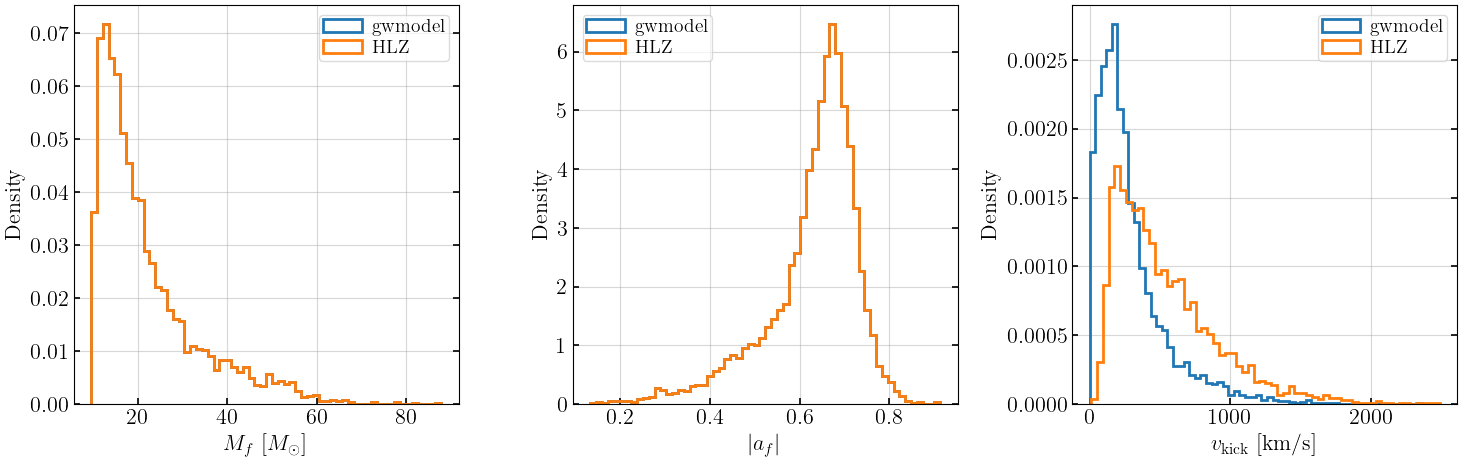

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels = ['gwmodel', 'HLZ']

axes[0].hist(rem_gw.Mf, bins=60, density=True, histtype='step', lw=2, label='gwmodel')
axes[0].hist(rem_hlz.Mf, bins=60, density=True, histtype='step', lw=2, label='HLZ')
axes[0].set_xlabel(r'$M_f$ [$M_\odot$]')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(rem_gw.af, bins=60, density=True, histtype='step', lw=2, label='gwmodel')
axes[1].hist(rem_hlz.af, bins=60, density=True, histtype='step', lw=2, label='HLZ')
axes[1].set_xlabel(r'$|a_f|$')
axes[1].set_ylabel('Density')
axes[1].legend()

axes[2].hist(rem_gw.vkick, bins=60, density=True, histtype='step', lw=2, label='gwmodel')
axes[2].hist(rem_hlz.vkick, bins=60, density=True, histtype='step', lw=2, label='HLZ')
axes[2].set_xlabel(r'$v_{\rm kick}$ [km/s]')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.show()

## JSD between kick models

In [6]:
jsd_Mf = compute_jensen_shannon_divergence(rem_gw.Mf, rem_hlz.Mf)
jsd_af = compute_jensen_shannon_divergence(rem_gw.af, rem_hlz.af)
jsd_vkick = compute_jensen_shannon_divergence(rem_gw.vkick, rem_hlz.vkick)

print(f"JSD(Mf):    {jsd_Mf:.6f}")
print(f"JSD(af):    {jsd_af:.6f}")
print(f"JSD(vkick): {jsd_vkick:.6f}")

JSD(Mf):    0.000000
JSD(af):    0.000000
JSD(vkick): 0.110305


## Scatter comparison

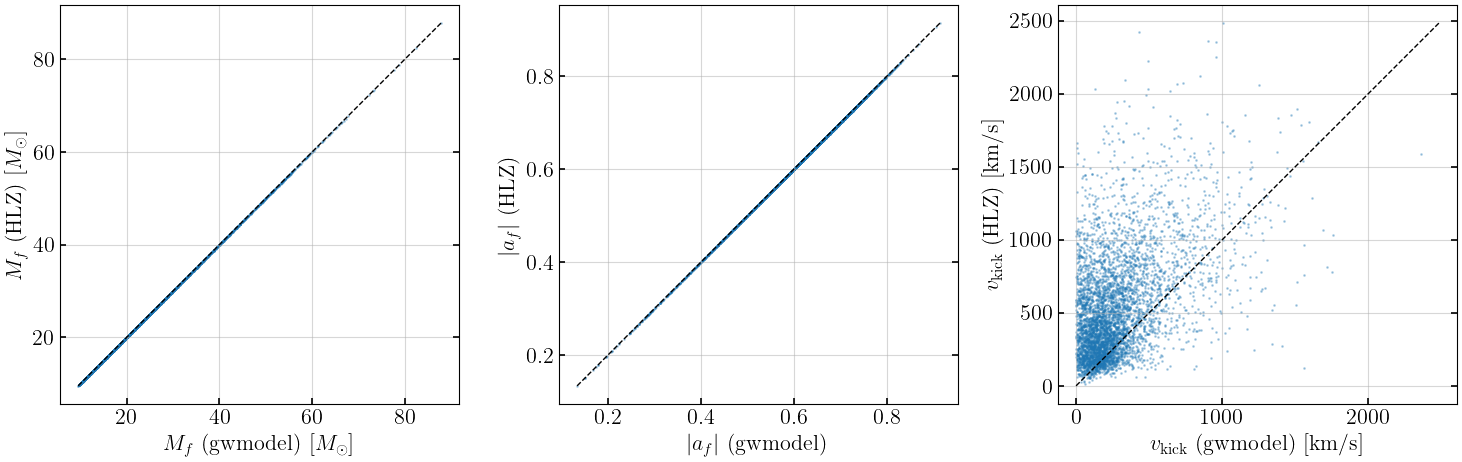

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(rem_gw.Mf, rem_hlz.Mf, s=1, alpha=0.3)
lims = [min(rem_gw.Mf.min(), rem_hlz.Mf.min()), max(rem_gw.Mf.max(), rem_hlz.Mf.max())]
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlabel(r'$M_f$ (gwmodel) [$M_\odot$]')
axes[0].set_ylabel(r'$M_f$ (HLZ) [$M_\odot$]')

axes[1].scatter(rem_gw.af, rem_hlz.af, s=1, alpha=0.3)
lims = [min(rem_gw.af.min(), rem_hlz.af.min()), max(rem_gw.af.max(), rem_hlz.af.max())]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set_xlabel(r'$|a_f|$ (gwmodel)')
axes[1].set_ylabel(r'$|a_f|$ (HLZ)')

axes[2].scatter(rem_gw.vkick, rem_hlz.vkick, s=1, alpha=0.3)
lims = [min(rem_gw.vkick.min(), rem_hlz.vkick.min()), max(rem_gw.vkick.max(), rem_hlz.vkick.max())]
axes[2].plot(lims, lims, 'k--', lw=1)
axes[2].set_xlabel(r'$v_{\rm kick}$ (gwmodel) [km/s]')
axes[2].set_ylabel(r'$v_{\rm kick}$ (HLZ) [km/s]')

plt.tight_layout()
plt.show()

## Surrogate models (surfinBH)

The `surfinBH` package provides NR surrogate remnant models. If installed, `BBHRemnant` can use
`NRSur7dq4Remnant` for precessing systems. This model covers mass ratios up to 4 and arbitrary
spin orientations.

In [8]:
try:
    rem_sur = BBHRemnant(bbh=bbh, precessing=True, mass_spin_model='sur7dq4remnant', kick_model='sur7dq4remnant')
    print(rem_sur)
except Exception as e:
    print(f"Surrogate not available: {e}")

Loaded NRSur7dq4Remnant fit.
BBHRemnant(n=5000, precessing=True, mass_spin=sur7dq4remnant, kick=sur7dq4remnant, Mf=[9.5, 87.9], af=[0.133, 0.909], vkick=[8.0, 2185.4] km/s)


BBHRemnant(n=5000, precessing=True, mass_spin=sur7dq4remnant, kick=sur7dq4remnant, Mf=[9.5, 87.9], af=[0.133, 0.909], vkick=[8.0, 2185.4] km/s)


JSD(Mf):    0.000499
JSD(af):    0.001781
JSD(vkick): 0.035856


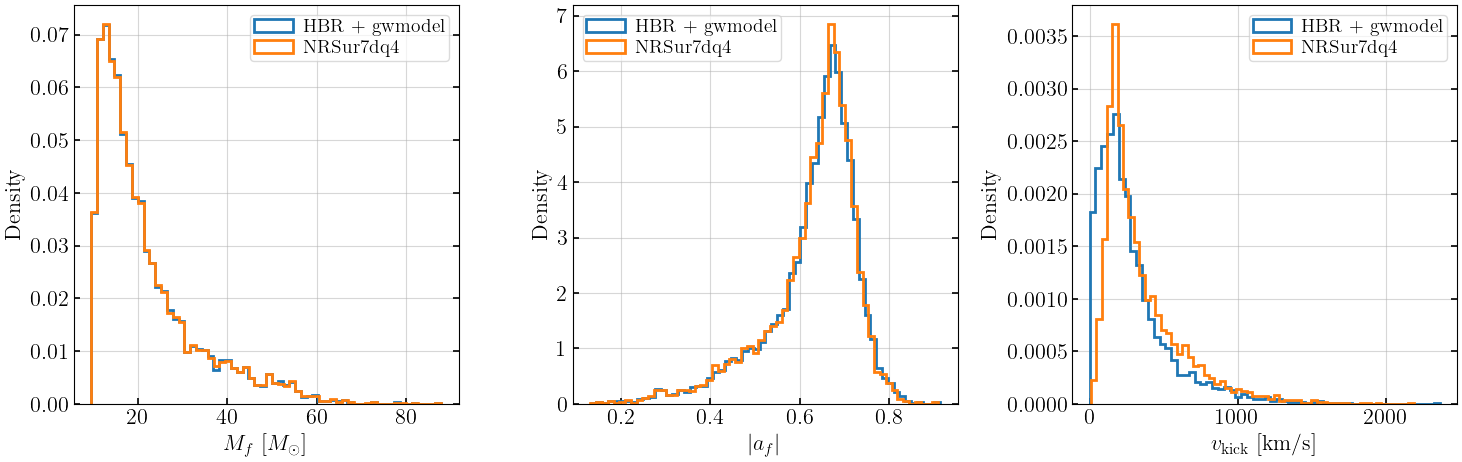

In [9]:
try:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].hist(rem_gw.Mf, bins=60, density=True, histtype='step', lw=2, label='HBR + gwmodel')
    axes[0].hist(rem_sur.Mf, bins=60, density=True, histtype='step', lw=2, label='NRSur7dq4')
    axes[0].set_xlabel(r'$M_f$ [$M_\odot$]')
    axes[0].set_ylabel('Density')
    axes[0].legend()

    axes[1].hist(rem_gw.af, bins=60, density=True, histtype='step', lw=2, label='HBR + gwmodel')
    axes[1].hist(rem_sur.af, bins=60, density=True, histtype='step', lw=2, label='NRSur7dq4')
    axes[1].set_xlabel(r'$|a_f|$')
    axes[1].set_ylabel('Density')
    axes[1].legend()

    axes[2].hist(rem_gw.vkick, bins=60, density=True, histtype='step', lw=2, label='HBR + gwmodel')
    axes[2].hist(rem_sur.vkick, bins=60, density=True, histtype='step', lw=2, label='NRSur7dq4')
    axes[2].set_xlabel(r'$v_{\rm kick}$ [km/s]')
    axes[2].set_ylabel('Density')
    axes[2].legend()

    jsd_Mf_sur = compute_jensen_shannon_divergence(rem_gw.Mf, rem_sur.Mf)
    jsd_af_sur = compute_jensen_shannon_divergence(rem_gw.af, rem_sur.af)
    jsd_vkick_sur = compute_jensen_shannon_divergence(rem_gw.vkick, rem_sur.vkick)
    print(f"JSD(Mf):    {jsd_Mf_sur:.6f}")
    print(f"JSD(af):    {jsd_af_sur:.6f}")
    print(f"JSD(vkick): {jsd_vkick_sur:.6f}")

    plt.tight_layout()
    plt.show()
except NameError:
    print("Surrogate model not available; skipping comparison plots.")

## Remnant properties vs binary parameters

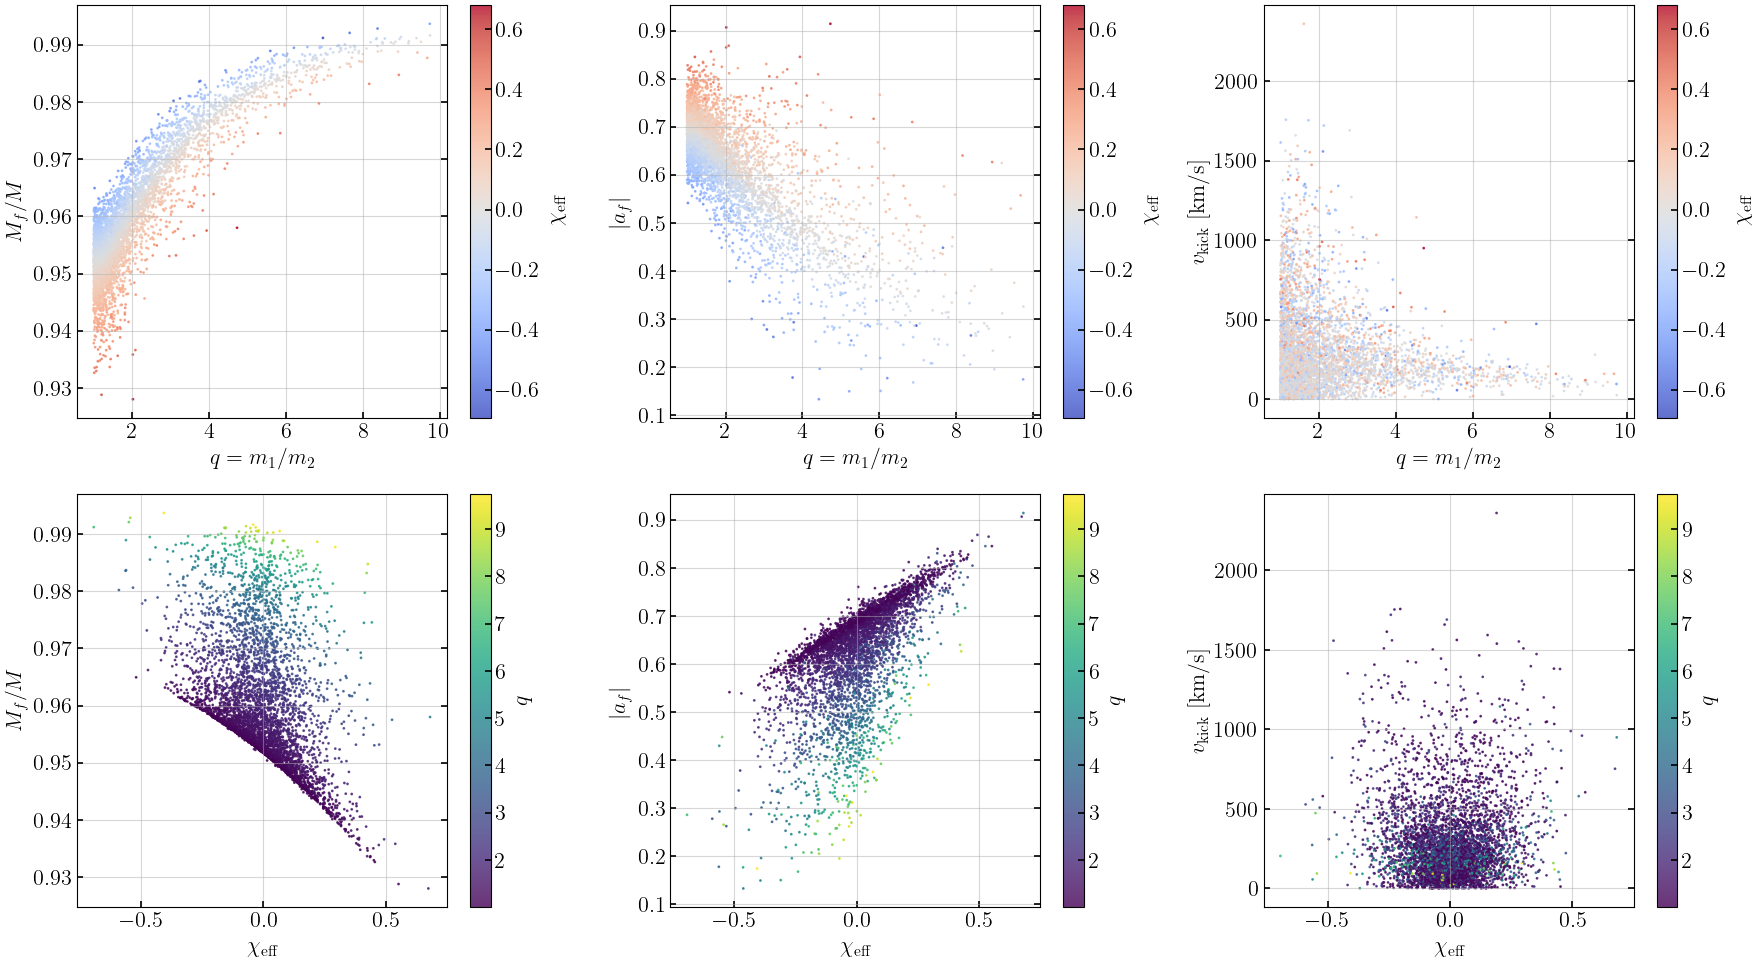

In [10]:
q = bbh.q
chi_eff = bbh.chi_eff

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Top row: q vs remnant properties, colored by chi_eff
sc0 = axes[0, 0].scatter(q, rem_gw.Mf / bbh.M, c=chi_eff, s=1, alpha=0.8, cmap='coolwarm')
axes[0, 0].set_xlabel(r'$q = m_1/m_2$')
axes[0, 0].set_ylabel(r'$M_f / M$')
plt.colorbar(sc0, ax=axes[0, 0], label=r'$\chi_{\rm eff}$')

sc1 = axes[0, 1].scatter(q, rem_gw.af, c=chi_eff, s=1, alpha=0.8, cmap='coolwarm')
axes[0, 1].set_xlabel(r'$q = m_1/m_2$')
axes[0, 1].set_ylabel(r'$|a_f|$')
plt.colorbar(sc1, ax=axes[0, 1], label=r'$\chi_{\rm eff}$')

sc2 = axes[0, 2].scatter(q, rem_gw.vkick, c=chi_eff, s=1, alpha=0.8, cmap='coolwarm')
axes[0, 2].set_xlabel(r'$q = m_1/m_2$')
axes[0, 2].set_ylabel(r'$v_{\rm kick}$ [km/s]')
plt.colorbar(sc2, ax=axes[0, 2], label=r'$\chi_{\rm eff}$')

# Bottom row: chi_eff vs remnant properties, colored by q
sc3 = axes[1, 0].scatter(chi_eff, rem_gw.Mf / bbh.M, c=q, s=1, alpha=0.8, cmap='viridis')
axes[1, 0].set_xlabel(r'$\chi_{\rm eff}$')
axes[1, 0].set_ylabel(r'$M_f / M$')
plt.colorbar(sc3, ax=axes[1, 0], label=r'$q$')

sc4 = axes[1, 1].scatter(chi_eff, rem_gw.af, c=q, s=1, alpha=0.8, cmap='viridis')
axes[1, 1].set_xlabel(r'$\chi_{\rm eff}$')
axes[1, 1].set_ylabel(r'$|a_f|$')
plt.colorbar(sc4, ax=axes[1, 1], label=r'$q$')

sc5 = axes[1, 2].scatter(chi_eff, rem_gw.vkick, c=q, s=1, alpha=0.8, cmap='viridis')
axes[1, 2].set_xlabel(r'$\chi_{\rm eff}$')
axes[1, 2].set_ylabel(r'$v_{\rm kick}$ [km/s]')
plt.colorbar(sc5, ax=axes[1, 2], label=r'$q$')

plt.tight_layout()
plt.show()